In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

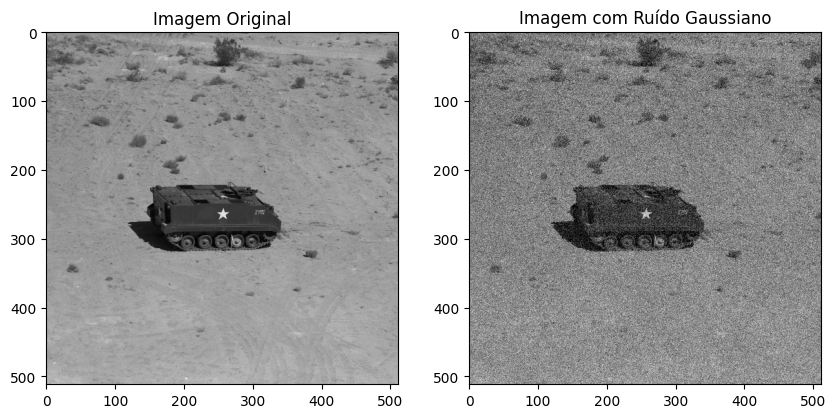

True

In [5]:
# Função para adicionar ruído gaussiano
def adicionar_ruido_gaussiano(imagem, media=0, desvio_padrao=25):
    row, col = imagem.shape
    gauss = np.random.normal(media, desvio_padrao, (row, col)).reshape(row, col)
    imagem_com_ruido = imagem + gauss
    imagem_com_ruido = np.clip(imagem_com_ruido, 0, 255)  # Garantir que os valores permaneçam dentro do intervalo válido
    return imagem_com_ruido.astype(np.uint8)

# Carregar a imagem em escala de cinza
imagem = cv2.imread('Dataset\\7.1.08.tiff', cv2.IMREAD_GRAYSCALE)

# Adicionar ruído gaussiano
imagem_ruidosa = adicionar_ruido_gaussiano(imagem)

# Exibir a imagem original e a imagem com ruído
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(imagem, cmap='gray'), plt.title('Imagem Original')
plt.subplot(1, 2, 2), plt.imshow(imagem_ruidosa, cmap='gray'), plt.title('Imagem com Ruído Gaussiano')
plt.show()

cv2.imwrite('img\\7.1.08-gaussiano.tiff',imagem_ruidosa)

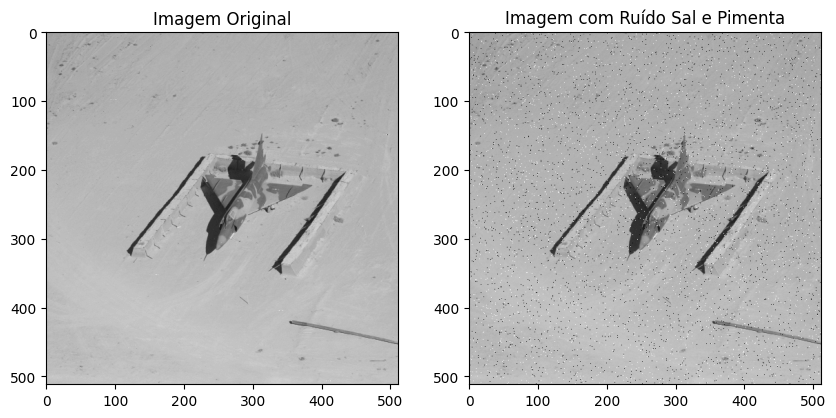

True

In [6]:
# Função para adicionar ruído sal e pimenta
def adicionar_ruido_sal_pimenta(imagem, probabilidade=0.02):
    row, col = imagem.shape
    imagem_com_ruido = np.copy(imagem)
    
    # Gerar uma máscara de ruído sal e pimenta
    salt_pepper = np.random.rand(row, col)
    
    # Aplicar ruído sal
    imagem_com_ruido[salt_pepper < probabilidade / 2] = 255
    
    # Aplicar ruído pimenta
    imagem_com_ruido[salt_pepper > 1 - (probabilidade / 2)] = 0
    
    return imagem_com_ruido

# Carregar a imagem em escala de cinza
imagem = cv2.imread('Dataset\\7.1.02.tiff', cv2.IMREAD_GRAYSCALE)

# Adicionar ruído sal e pimenta
imagem_ruidosa = adicionar_ruido_sal_pimenta(imagem)

# Exibir a imagem original e a imagem com ruído
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(imagem, cmap='gray'), plt.title('Imagem Original')
plt.subplot(1, 2, 2), plt.imshow(imagem_ruidosa, cmap='gray'), plt.title('Imagem com Ruído Sal e Pimenta')
plt.show()

# Exportar a imagem com ruído
cv2.imwrite('img\\7.1.02-saltpepper.tiff', imagem_ruidosa)